<a href="https://colab.research.google.com/github/janpeter19/BPL_TEST2_Batch/blob/main/BPL_TEST2_Batch_oms_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BPL_TEST2_Batch script with OMSimulator

The key library OMSimulator is installed.

After the installation a small application BPL_TEST2_Batch is loaded and run. You can continue with this example if you like.

In [1]:
!lsb_release -a # Actual VM Ubuntu version used by Google

No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 24.04.5 LTS
Release:	24.04
Codename:	noble


In [2]:
!python --version

Python 3.13.15


In [3]:
!pip install OMSimulator

In [4]:
!pip install DyMat

# BPL_TEST2_Batch setup


Now specific installation and the run simulations. Start with connecting to Github. Then upload the two files:

* FMU - BPL_TEST2_Batch_linux_om_me.fmu
* Setup-file - BPL_TEST2_Batch_fmpy_explore.py

In [5]:
%%bash
git clone https://github.com/janpeter19/BPL_TEST2_Batch

fatal: destination path 'BPL_TEST2_Batch' already exists and is not an empty directory.


CalledProcessError: Command 'b'git clone https://github.com/janpeter19/BPL_TEST2_Batch\n'' returned non-zero exit status 128.

In [6]:
%cd BPL_TEST2_Batch

/content/BPL_TEST2_Batch


## BPL_TEST2_Batch - demo



In [7]:
import OMSimulator as oms

In [8]:
import scipy.io

In [9]:
import DyMat

In [10]:
import matplotlib.pyplot as plt

## Basic simulation

In [11]:
fmu = oms.FMU('BPL_TEST2_Batch_linux_om_me.fmu')

In [12]:
fmu.modelName

'BPL.Examples_TEST2.Batch'

In [13]:
for s in fmu.states:
  print(s.name)

bioreactor.V
bioreactor.m[1]
bioreactor.m[2]


In [14]:
fmu.instantiate()

In [15]:
fmu.setResultFile('result.mat')

In [16]:
fmu.setValue('bioreactor.V_start', 1.0)
fmu.setValue('bioreactor.m_start[1]', 1.0)
fmu.setValue('bioreactor.m_start[2]', 10.0)

In [17]:
fmu.initialize()

In [18]:
fmu.simulate()

In [19]:
mat_data = scipy.io.loadmat('result.mat')

In [20]:
mat_data.keys()

dict_keys(['Aclass', 'name', 'description', 'dataInfo', 'data_1', 'data_2'])

In [21]:
t = mat_data['data_2'][0];

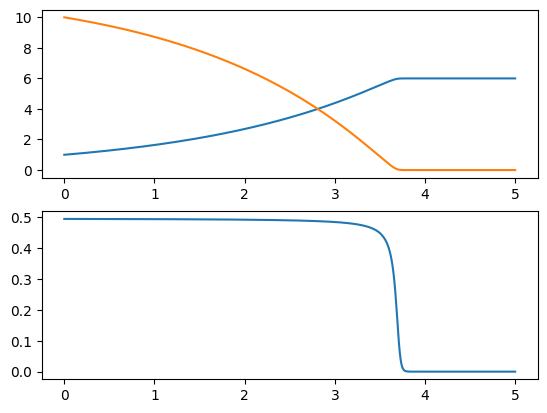

In [22]:
plt.figure()

ax1 = plt.subplot(2,1,1)
ax2 = plt.subplot(2,1,2)

ax1.plot(t, mat_data['data_2'][2])
ax1.plot(t, mat_data['data_2'][3])
ax2.plot(t, mat_data['data_2'][12])
plt.show()

Simulation looks what I expected!

## How to address variables using names

In [23]:
res = DyMat.DyMatFile('result.mat')

In [24]:
print(res.names())

dict_keys(['Batch.bioreactor.V', 'Batch.bioreactor.m[1]', 'Batch.bioreactor.m[2]', 'Batch.der(bioreactor.V)', 'Batch.der(bioreactor.m[1])', 'Batch.der(bioreactor.m[2])', 'Batch.bioreactor.W', 'Batch.bioreactor.broth_decay.r[1]', 'Batch.bioreactor.broth_decay.r[2]', 'Batch.bioreactor.c[1]', 'Batch.bioreactor.c[2]', 'Batch.bioreactor.culture.q[1]', 'Batch.bioreactor.culture.q[2]', 'Batch.bioreactor.gas_liquid_transfer.r_to_liquid[1]', 'Batch.bioreactor.gas_liquid_transfer.r_to_liquid[2]', 'Batch.bioreactor.pH_buffer.r[1]', 'Batch.bioreactor.pH_buffer.r[2]', 'Batch.bioreactor.culture.mu', 'Batch.bioreactor.X', 'Batch.bioreactor.n_inlets', 'Batch.bioreactor.n_outlets', 'Batch.bioreactor.n_ports', 'Batch.bioreactor.V_start', 'Batch.bioreactor.culture.Ks', 'Batch.bioreactor.culture.Y', 'Batch.bioreactor.culture.qSmax', 'Batch.bioreactor.m_start[1]', 'Batch.bioreactor.m_start[2]', 'Batch.bioreactor.p'])


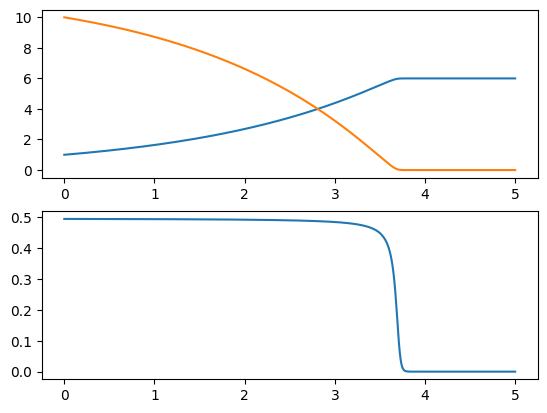

In [25]:
plt.figure()

ax1 = plt.subplot(2,1,1)
ax2 = plt.subplot(2,1,2)

ax1.plot(t, res['Batch.bioreactor.m[1]'])
ax1.plot(t, res['Batch.bioreactor.m[2]'])
ax2.plot(t, res['Batch.bioreactor.culture.mu'])
plt.show()

How to address "time" in the res-file?